In [ ]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation


c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = BNCI2014_001()
dataset.metadata

DatasetMetadata(acquisition=AcquisitionMetadata(sampling_rate=250.0, n_channels=25, channel_types={'eeg': 22, 'eog': 3}, sensors=['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CPz', 'Cz', 'EOG1', 'EOG2', 'EOG3', 'FC1', 'FC2', 'FC3', 'FC4', 'FCz', 'Fz', 'P1', 'P2', 'POz', 'Pz'], sensor_type='Ag/AgCl', reference='left mastoid', ground='unknown', hardware='BrainAmp MR plus', software='BCI2000', filters='bandpass 0.05-200 Hz', line_freq=50.0, montage='custom', impedance_threshold_kohm=None, auxiliary_channels=AuxiliaryChannelsMetadata(has_eog=False, eog_channels=None, eog_type=None, has_emg=False, emg_channels=None, other_physiological=None), cap_manufacturer='EASYCAP GmbH', cap_model=None, electrode_type=None, electrode_material=None), participants=ParticipantMetadata(n_subjects=9, health_status='healthy', gender=None, age_mean=None, age_std=None, age_min=None, age_max=None, ages=None, handedness=None, clinical_population=None, bci_experience=None, sexes=None, handednes

In [3]:
missing=['C1', 'FC1','Fz']

channels=['C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 
        'CP4', 'CPz', 'Cz', 'FC2','FC3', 'FC4', 'FCz', 'P1', 
        'P2', 'POz', 'Pz']

In [4]:
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"], channels=channels)


Choosing from all possible events


In [5]:
pipeline = make_pipeline(
            CSP(n_components=8),
            LDA()
        )

In [6]:
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [7]:
results = evaluation.process({"csp+lda-missingChannels": pipeline})

Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 19 dim * 9.1e+15  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 19 dim * 9.2e+15  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 19 dim * 9e+15

In [8]:
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

avgRes

,Accuracy,Balanced Accuracy,score_f1_macro
session,,,
0train,0.647214,0.647513,0.644330
1test,0.697896,0.698466,0.695106


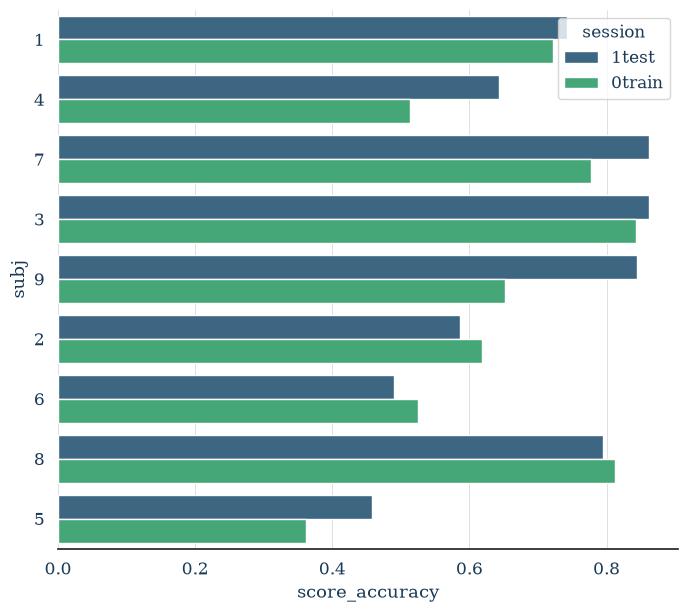

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

## Run 10 combinations, avg performance

In [65]:
import random

channels=['C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 
        'CP4', 'CPz', 'Cz', 'FC2','FC3', 'FC4', 'FCz', 'P1', 
        'P2', 'POz', 'Pz','C1', 'FC1','Fz']


In [66]:
import random

all_missings = []
used_combinations = set()

base_channels = [
    'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3',
    'CP4', 'CPz', 'Cz', 'FC2', 'FC3', 'FC4', 'FCz',
    'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz'
]

while len(all_missings) < 10:
    missings = sorted(random.sample(base_channels, 4))
    key = tuple(missings)

    if key in used_combinations:
        continue

    used_combinations.add(key)
    all_missings.append(missings)

print(all_missings)

[['C2', 'CP1', 'FC1', 'FCz'], ['CP2', 'CP3', 'FC1', 'FCz'], ['C1', 'C6', 'CP1', 'FC2'], ['CP2', 'FC1', 'Fz', 'POz'], ['C2', 'C5', 'CP2', 'Cz'], ['C2', 'CP4', 'FC1', 'FC3'], ['FC2', 'FC4', 'FCz', 'POz'], ['C5', 'CP4', 'FCz', 'Fz'], ['C4', 'CPz', 'Cz', 'P2'], ['CP1', 'FC2', 'FCz', 'P1']]


In [67]:
all_results = []
all_avgs = []

for missings in all_missings:

    channels = [ch for ch in base_channels if ch not in missings]

    paradigm = mp.MotorImagery(
        scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        channels=channels
    )

    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=True,
        hdf5_path=None
    )

    results = evaluation.process({"csp+lda": pipeline})
    all_results.append(results)

    
    avgRes=[]
    avgRes=pd.DataFrame(avgRes)
    avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
    avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
    avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()


    all_avgs.append(avgRes)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 18 dim * 7e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 18 dim * 6.9e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 18 dim * 7e+15  

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 35 (2.2e-16 eps * 18 dim * 8.7e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 35 (2.2e-16 eps * 18 dim * 8.6e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 35 (2.2e-16 eps * 18 dim * 8.8e+

Choosing from all possible events


...

Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 18 dim * 1.6e+16  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 63 (2.2e-16 eps * 18 dim * 1.6e+16  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 61 (2.2e-16 eps * 18 dim * 1.5e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 33 (2.2e-16 eps * 18 dim * 8.3e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 33 (2.2e-16 eps * 18 dim * 8.2e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 33 (2.2e-16 eps * 18 dim * 8.2e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 18 dim * 9.6e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 18 dim * 9.7e+15  max singular value)
    Estimated rank (data): 18
    data: rank 18 computed from 18 data channels with 0 projectors
Reducing data rank from 18 -> 18
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 18 dim * 9.5e+

In [68]:
TrainAccuracy=0
TestAccuracy=0
BTrainAccuracy=0
BTestAccuracy=0
FTrain=0
FTest=0
num=10

for dset in all_avgs:
    TrainAccuracy+=dset.iloc[0]['Accuracy']
    TestAccuracy+=dset.iloc[1]['Accuracy']
    BTrainAccuracy+=dset.iloc[0]['Balanced Accuracy']
    BTestAccuracy+=dset.iloc[1]['Balanced Accuracy']
    FTrain+=dset.iloc[0]['score_f1_macro']
    FTest+=dset.iloc[1]['score_f1_macro']

print("Train")
print("Avg accuracy= ", TrainAccuracy/num)
print("Avg balanced accuracy= ", BTrainAccuracy/num)
print("Avg macro F1= ", FTrain/num)

print("\nTest")
print("Avg accuracy= ", TestAccuracy/num)
print("Avg balanced accuracy= ", BTestAccuracy/num)
print("Avg macro F1= ", FTest/num)



Train
Avg accuracy=  0.6424777
Avg balanced accuracy=  0.6426588
Avg macro F1=  0.63930774

Test
Avg accuracy=  0.68860185
Avg balanced accuracy=  0.68883336
Avg macro F1=  0.68641126


In [69]:
import pandas as pd

results = pd.concat(all_results, ignore_index=True)

avg_results = (
    results
    .groupby(["subject", "session"], as_index=False)["score_accuracy"]
    .mean()
)

print(avg_results)

   subject session  score_accuracy
0        1  0train        0.741053
1        1   1test        0.733739
2        2  0train        0.602710
3        2   1test        0.578476
4        3  0train        0.843636
5        3   1test        0.847217
6        4  0train        0.520865
7        4   1test        0.647296
8        5  0train        0.369746
9        5   1test        0.447235
10       6  0train        0.480466
11       6   1test        0.467169
12       7  0train        0.762154
13       7   1test        0.834283
14       8  0train        0.813751
15       8   1test        0.795439
16       9  0train        0.647919
17       9   1test        0.846564


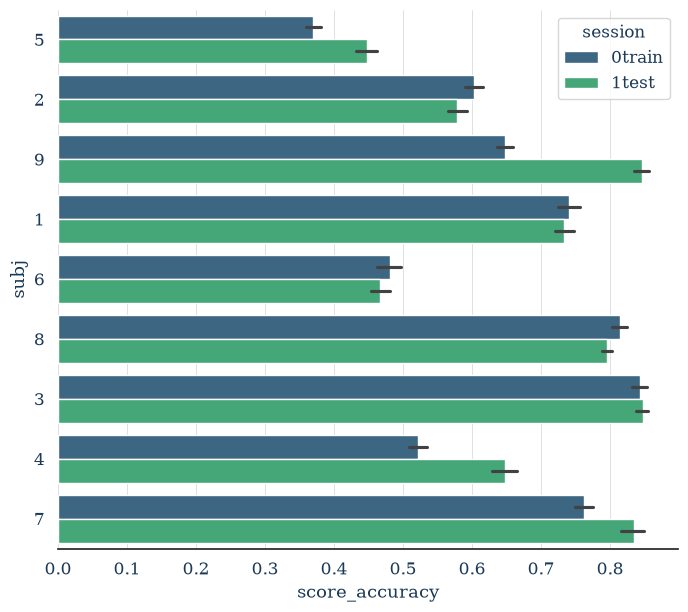

In [70]:
fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()
